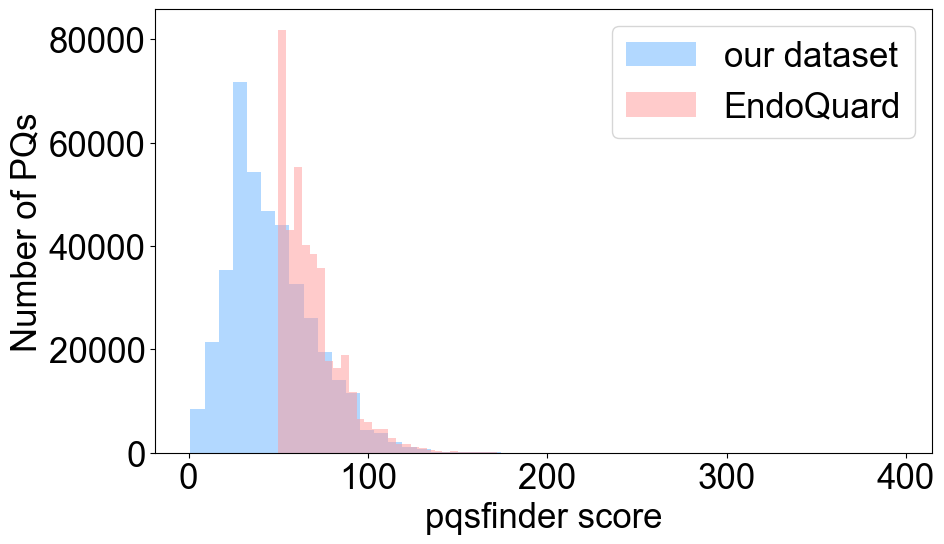

✅ 图片已成功保存到：bed_score_hist.svg


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ====================== 你只需要改这里 ======================
bed1_path = "_Ourdataset_score.bed"
bed2_path = "_EndoQuard.bed"
save_fig = "bed_score_hist.svg"
# ==========================================================

# 1. 读取数据
bed1 = pd.read_csv(bed1_path, sep="\t", header=None)
bed2 = pd.read_csv(bed2_path, sep="\t", header=None)
score1 = bed1[3]   # ourdata
score2 = bed2[4]   # EndoQuard

# 2. 字体设置
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 25

# 3. 画图
plt.figure(figsize=(10,6))
plt.hist(score1, bins=50, alpha=0.5, label="our dataset", color="#66b3ff")
plt.hist(score2, bins=50, alpha=0.5, label="EndoQuard", color="#ff9999")

# 标签
plt.xlabel("pqsfinder score")
plt.ylabel("Number of PQs")
plt.legend()

# ====================== 关键修复 ======================
# 1. 先保存图片
plt.tight_layout()  # 防止文字被截断
plt.savefig(save_fig, dpi=300, bbox_inches='tight')

# 2. 再展示
plt.show()
plt.close()
# ======================================================

print(f"✅ 图片已成功保存到：{save_fig}")

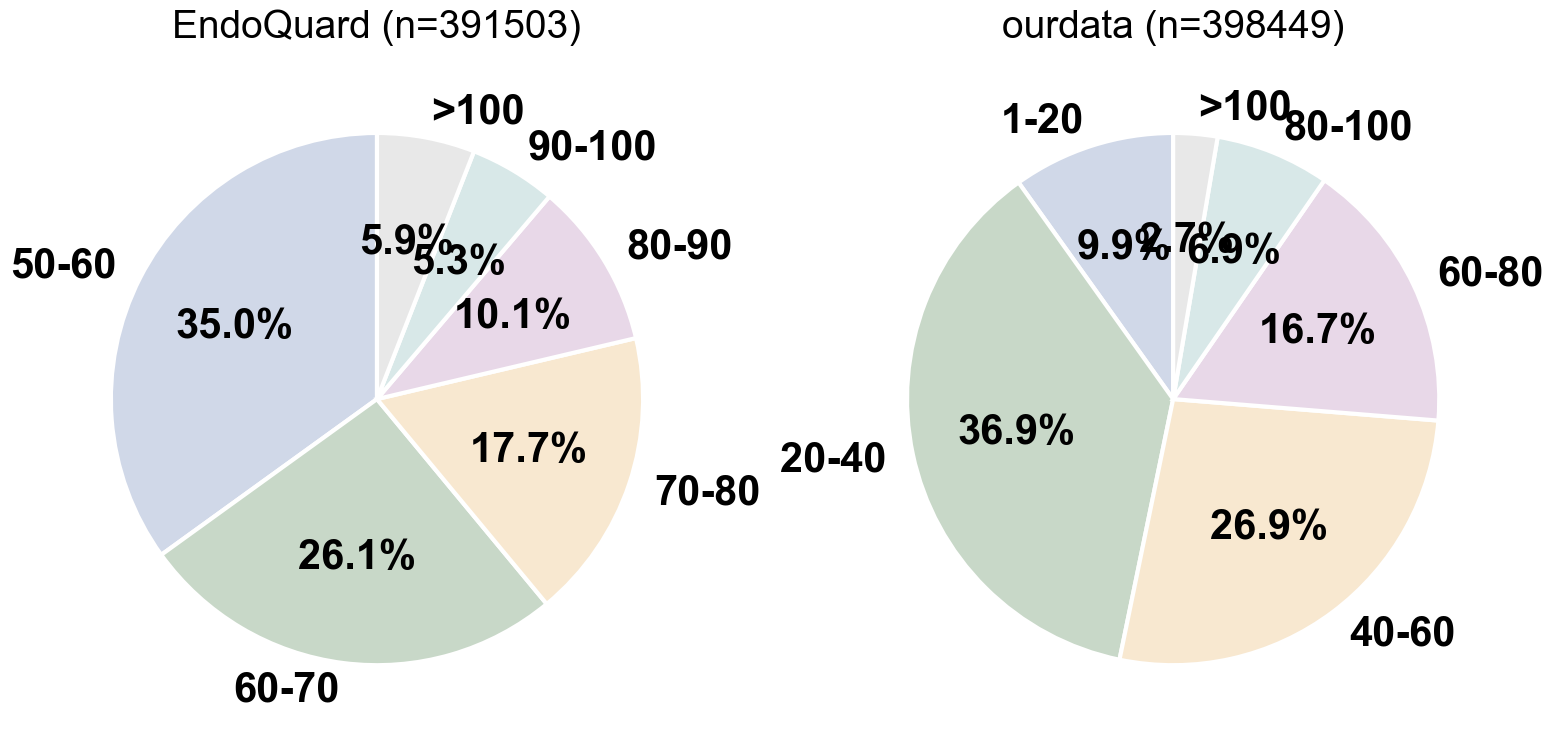

✅ 双饼图已保存：pqs_score_two_pies_final.svg

📊 EndoQuard (≥50) 各分数段：
4
50-60     136838
60-70     102019
70-80      69187
80-90      39513
90-100     20690
>100       23256
Name: count, dtype: int64

📊 ourdata (从1开始) 各分数段：
3
1-20       39315
20-40     147034
40-60     107360
60-80      66385
80-100     27681
>100       10674
Name: count, dtype: int64


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

save_fig = "pqs_score_two_pies_final.svg"
# ==========================================================

# 1. 读取数据
# bed1 = pd.read_csv(bed1_path, sep="\t", header=None)
# bed2 = pd.read_csv(bed2_path, sep="\t", header=None)

# ===================== 正确分组 =====================
score_our  = bed1[3]   # ourdata
score_endo = bed2[4]   # EndoQuard

# 筛选：EndoQuard 只保留 ≥50 的数据
score_endo = score_endo[score_endo >= 50]

# ===================== 两个数据集使用不同区间 =====================
# 1. EndoQuard：50起步
bins_endo = [50, 60, 70, 80, 90, 100, np.inf]
labels_endo = ['50-60', '60-70', '70-80', '80-90', '90-100', '>100']

# 2. ourdata：从1开始（0-20实际包含1开始）
bins_our = [0, 20, 40, 60, 80, 100, np.inf]
labels_our = ['1-20', '20-40', '40-60', '60-80', '80-100', '>100']

# 柔和颜色
colors = ['#D0D8E8','#C8D8C8','#F8E8D0','#E8D8E8','#D8E8E8','#E8E8E8']

# 统计函数
def count_scores(scores, bins, labels):
    return pd.cut(scores, bins=bins, labels=labels, right=False).value_counts(sort=False)

count_endo = count_scores(score_endo, bins_endo, labels_endo)
count_our  = count_scores(score_our, bins_our, labels_our)

# ===================== 字体设置 =====================
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 30
plt.rcParams['font.weight'] = 'bold'

# 画图
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# ------------------- 左图：EndoQuard (≥50) -------------------
wedges1, texts1, autotexts1 = ax1.pie(
    count_endo, labels=labels_endo, colors=colors, autopct='%1.1f%%',
    startangle=90, textprops={'fontsize': 30, 'weight':'bold'},
    wedgeprops={'edgecolor':'white','linewidth':3}
)
ax1.set_title(f'EndoQuard (n={len(score_endo)})', fontsize=28, pad=30)

# ------------------- 右图：ourdata (从1开始) -------------------
wedges2, texts2, autotexts2 = ax2.pie(
    count_our, labels=labels_our, colors=colors, autopct='%1.1f%%',
    startangle=90, textprops={'fontsize': 30, 'weight':'bold'},
    wedgeprops={'edgecolor':'white','linewidth':3}
)
ax2.set_title(f'ourdata (n={len(score_our)})', fontsize=28, pad=30)

# 百分比文字
for autotext in autotexts1 + autotexts2:
    autotext.set_color('black')
    autotext.set_fontsize(30)
    autotext.set_weight('bold')

ax1.axis('equal')
ax2.axis('equal')

plt.tight_layout()
plt.savefig(save_fig, bbox_inches='tight')
plt.show()
plt.close()

print(f"✅ 双饼图已保存：{save_fig}")
print(f"\n📊 EndoQuard (≥50) 各分数段：")
print(count_endo)
print(f"\n📊 ourdata (从1开始) 各分数段：")
print(count_our)